# 🏠 Neural Networks for Property Valuation

## The situation

You have just joined the **valuation desk of a regional real-estate agency**. Every week your
agents walk in with new listings and ask the same question: *what price do we put on it?*

Today that answer comes from a human appraiser — roughly **three days** of work and a few
hundred dollars per property. Your head of sales wants to know whether the **10,000 properties
already on your books** are enough to train a model that prices the routine listings on its own,
so appraisers can spend their time on the unusual ones.

That is the decision you are working towards. Along the way this notebook answers:

1. **Which features actually move a price?** — size, rooms, age, distance to the centre.
2. **How do we build a neural network** that turns those four numbers into a price?
3. **How do we train it — and how do we know when to stop**, before it starts memorising
   the properties it has already seen?
4. **How wrong is it, in dollars?** And is "that wrong" small enough to send a listing to
   market without an appraiser?

The answer to question 4 is the one your head of sales cares about. Everything else is how
you earn the right to give it.

---

In [1]:
#@title 🗺️ Roadmap — the six steps ahead (double-click to view the code) { display-mode: "form" }
import uuid
from IPython.display import HTML, display

_uid = uuid.uuid4().hex[:8]

_steps = [
    ("📊", "1. Explore",  "What is in the data?"),
    ("🔧", "2. Prepare",  "Split &amp; scale"),
    ("🧠", "3. Build",    "Design the network"),
    ("🏋️", "4. Train",    "Learn, then stop in time"),
    ("📏", "5. Evaluate", "How wrong, in dollars?"),
    ("📈", "6. Decide",   "Automate it — or not"),
]

_cards = "".join(
    f"""<div class="step">
          <div class="icon">{icon}</div>
          <div class="label">{label}</div>
          <div class="sub">{sub}</div>
        </div>"""
    for icon, label, sub in _steps
)

display(HTML(f"""
<style>
#rm-{_uid} {{
  font-family: system-ui, "Segoe UI", Roboto, sans-serif;
  background: linear-gradient(135deg, #f6f8ff, #fbf5ff);
  border: 1px solid #ecebff; border-radius: 18px;
  padding: 22px 20px; margin: 6px 0;
}}
#rm-{_uid} h3 {{
  margin: 0 0 16px 0; font-size: 15px; font-weight: 600;
  color: #3b3663; letter-spacing: .02em;
}}
#rm-{_uid} .row {{ display: flex; flex-wrap: wrap; gap: 12px; }}
#rm-{_uid} .step {{
  flex: 1 1 150px; background: #fff; border: 1px solid #e6e8ee;
  border-radius: 14px; padding: 14px 12px; text-align: center;
}}
#rm-{_uid} .icon {{
  width: 46px; height: 46px; margin: 0 auto 10px auto; border-radius: 50%;
  background: linear-gradient(135deg, #667eea, #764ba2);
  display: flex; align-items: center; justify-content: center;
  font-size: 22px; line-height: 1;
}}
#rm-{_uid} .label {{ font-size: 14px; font-weight: 650; color: #2c2b3d; }}
#rm-{_uid} .sub {{ font-size: 12px; color: #6b6a80; margin-top: 4px; }}
</style>

<div id="rm-{_uid}">
  <h3>🗺️ From 10,000 old listings to a pricing decision</h3>
  <div class="row">{_cards}</div>
</div>
"""))

## 📦 Step 0 — Install the tools

Before we begin we install the libraries this notebook depends on:

| Library | Purpose |
|---------|----------|
| `torch` | PyTorch — the deep learning framework we use to build and train the network |
| `scikit-learn` | Utilities for splitting and scaling data |
| `kagglehub` | Downloads the dataset directly from Kaggle |
| `pandas` | Works with tabular data (like an Excel spreadsheet) |
| `numpy` | Fast numerical operations on arrays |
| `matplotlib` / `seaborn` | Charts and visualisations |

The same cell also fetches **`utils.py`**, the helper file that holds all the boilerplate.

**Run this cell once** — it may take a minute. It is safe to run again: it will not
re-download anything it already has.

> 💡 If Colab asks you to restart the runtime after the install, do it
> (**Runtime → Restart runtime**) and then re-run the cells from the top.

In [3]:
#@title 📦 Setup — install packages and fetch the helper file (double-click to view the code) { display-mode: "form" }
import os
import urllib.request

%pip install torch scikit-learn kagglehub pandas numpy matplotlib seaborn --quiet

# ── Where utils.py can come from, in order of preference ───────────────────────
#    (needs_token, url). The private course repo is tried first, but only when a
#    GitHub token is available; the public mirror needs no credentials at all.
UTILS_SOURCES = [
    (True,  "https://raw.githubusercontent.com/eth-bmai-hs26/w1-cx-private/cx-nn/utils.py"),
    (False, "https://raw.githubusercontent.com/eth-bmai-hs26/w1-cx-public/main/cx-nn/utils.py"),
    (False, "https://raw.githubusercontent.com/eth-bmai-fs26/coding-exercises/week1/cx3-intro-to-nns/utils.py"),
]


def _github_token():
    """Find a GitHub token: Colab Secrets → environment variable → none."""
    try:
        from google.colab import userdata
        token = userdata.get("GITHUB_TOKEN")
        if token:
            return token
    except Exception:
        pass
    return os.environ.get("GITHUB_TOKEN")


def _fetch_utils():
    """Download utils.py unless it is already here. Never raises."""
    if os.path.exists("utils.py"):
        print("✅ utils.py is already here — nothing to download.")
        return True

    token = _github_token()
    for needs_token, url in UTILS_SOURCES:
        if needs_token and not token:
            continue
        try:
            request = urllib.request.Request(url)
            if needs_token:
                request.add_header("Authorization", f"token {token}")
            with urllib.request.urlopen(request, timeout=20) as response:
                content = response.read()
            with open("utils.py", "wb") as handle:
                handle.write(content)
            print(f"✅ Downloaded utils.py from {url.split('/')[3]}/{url.split('/')[4]}")
            return True
        except Exception as error:
            print(f"⚠️  Could not fetch utils.py from {url.split('/')[4]} ({type(error).__name__}).")

    print("❌ utils.py could not be downloaded. Upload it manually with the 📁 "
          "file browser on the left, then re-run this cell.")
    return False


_fetch_utils()
print("✅ Setup complete!")

✅ utils.py is already here — nothing to download.
✅ Setup complete!


## 📦 Step 1 — Import everything

All the helper code lives in **`utils.py`**. One import gives us the libraries **and** the
helper functions that handle the parts of this notebook that are not the point of the lesson
(downloading data, drawing charts, printing metrics).

Think of it as: *installing = buying the toolbox, `from utils import *` = opening the whole
toolbox on your workbench at once.*

The same cell also fixes the **random seed**. Neural networks start from randomly initialised
weights, so without a fixed seed you and the person next to you would get slightly different
numbers from identical code. With it, everyone in the room sees the same results.

> 💡 Open `utils.py` at any time to see exactly what each helper does.

In [4]:
# Libraries + helper functions, all in one line (see utils.py)
from utils import *

# One seed for the whole notebook: same split, same starting weights, same numbers.
set_seed(RANDOM_STATE)

print(f"✅ Everything imported — random seed fixed at {RANDOM_STATE}.")

✅ Everything imported — random seed fixed at 42.


---

# 📊 1. Data Loading & Exploration

## The properties already on your books

Your agency's archive holds **10,000 sold properties**. Each one is described by four facts
your agents record for every listing, plus the price it eventually sold for:

| Column | What it means |
|---------|------------|
| `square_feet` | Size of the house in square feet |
| `num_rooms` | Number of rooms |
| `age` | Age of the house in years |
| `distance_to_city(km)` | Distance from the city centre, in km |
| `price` | The price the house sold for — **this is what we want to predict** |

Four inputs is a small number, and that is deliberate: these are the fields your agents
actually fill in for every property, not the fields a data scientist would wish for.

The cell below downloads the dataset from Kaggle. If that download is unavailable — no
internet in the lecture room, a Kaggle rate limit — it falls back to an offline stand-in with
the same columns, so the notebook always runs. The stand-in holds *different* houses, so if
you see the fallback message your dollar figures will differ from your neighbour's; every
lesson below still holds.

In [5]:
# Download, load and clean the dataset — all in one step
df = load_dataset()

df.head()

100%|██████████| 292k/292k [00:00<00:00, 67.8MB/s]

Extracting files...
Dataset loaded: 10000 houses, 5 columns
After removing extreme outliers: 9820 houses remaining
Dataset ready!



/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,square_feet,num_rooms,age,distance_to_city(km),price
0,2248.357077,3,92,22.997972,200374.090410
1,1930.867849,2,22,13.984254,268784.847337
2,2323.844269,6,33,21.500945,315020.857676
3,2761.514928,3,63,10.343638,355111.468459
4,1882.923313,7,54,25.485200,234197.123903


### Look before you model

Never train on data you have not looked at. Four charts, four questions:

1. **Price distribution** — is it symmetric, or skewed towards a few expensive outliers?
2. **Feature correlations** — which of the four facts move the price, and in which direction?
3. **Size vs price** — the relationship every estate agent claims to know by heart.
4. **Age vs price** — does age make a property cheaper, or is "character" worth paying for?

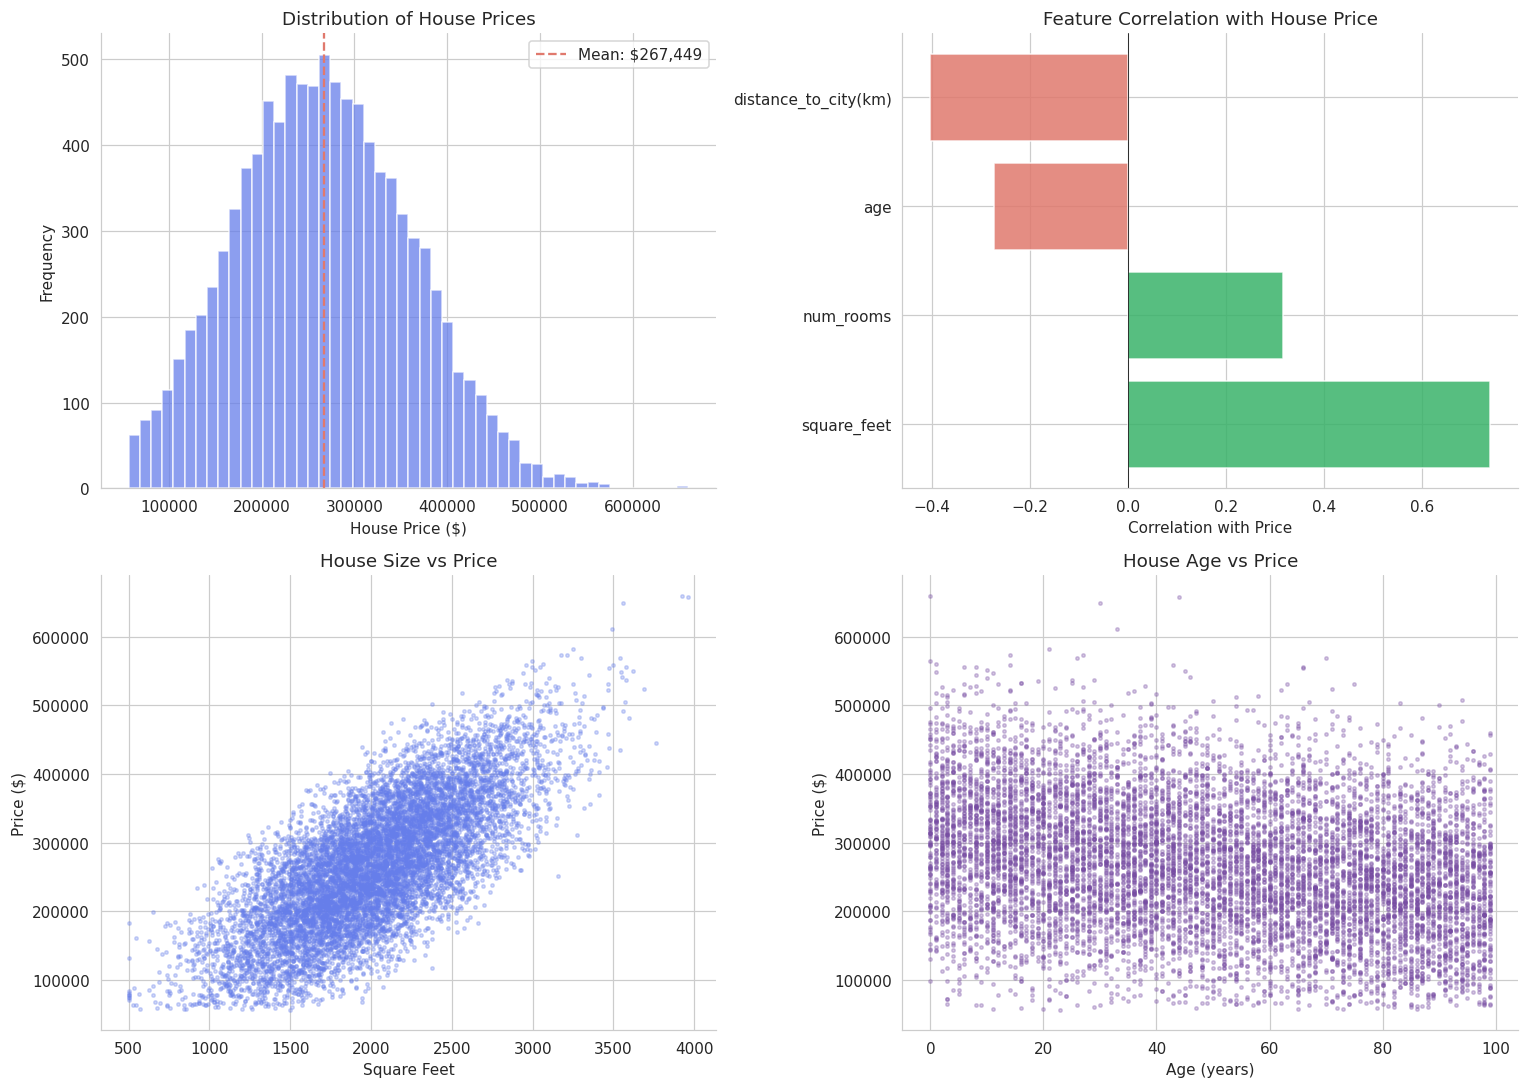

In [6]:
# Four charts to explore the data before we build anything
plot_dataset(df)

### 📖 Reading the charts

- **Size is your strongest single predictor.** The correlation bar for `square_feet` is by far
  the longest, and the size-vs-price scatter is an obvious upward band. If you had to price a
  property with one number, this would be the number.
- **But the band is *wide*.** At any given size the sold prices spread over a large range —
  that spread is exactly the part a size-only rule of thumb gets wrong, and the part the other
  three features (and the network) have to explain.
- **Age and distance pull the price down**, rooms pull it up. Nothing surprising — which is
  good news: it means the archive is behaving like the market your agents describe, and the
  model is not about to learn something absurd.
- **No single feature explains the price on its own.** That is the case for a model that
  combines all four rather than a spreadsheet formula on the largest one.

---

# 🔧 2. Data Preparation

Raw data cannot go straight into a neural network. Four steps first:

1. **Separate features from target** — the four facts go in, the price is what we predict.
2. **Split** the archive into training, validation and test sets.
3. **Scale** the values so every feature lives on a similar numeric range. Without this,
   `square_feet` (in the thousands) would shout over `num_rooms` (in the units) purely
   because its numbers are bigger.
4. **Convert** everything to PyTorch tensors.

## Why three sets, and not just two?

| Set | Share | Its role | The business analogy |
|-----|-----------|------|----|
| Training | 80% | The model **learns** from it | The deals your team has closed |
| Validation | 10% | We **monitor** it while training to spot memorisation | Your dress rehearsal |
| Test | 10% | **Final evaluation**, looked at once, at the end | Opening night |

The test set is the honest one. The moment you start tuning against it, it stops being a
measure of what happens on properties you have never seen — and that number is the only one
your head of sales should be shown.

### One call does all four steps

`prepare_data(df)` performs the whole preparation:

- **2a.** Separates the features (`square_feet`, `num_rooms`, `age`, `distance_to_city`) from
  the target (`price`)
- **2b.** Splits 80% training / 10% validation / 10% test
- **2c.** Standardises every column to mean 0 and standard deviation 1 — **fitted on the
  training set only**, so no information from the test set leaks backwards
- **2d.** Converts everything to PyTorch tensors

It gives back the tensors we train on, the **original test prices in dollars** (so we can
report errors in money rather than in scaled units), and the `price_scaler` needed to convert
the model's output back into dollars.

> 💡 Open `utils.py` to read the full implementation of `prepare_data()`.

In [7]:
# Split into train/val/test, scale, and convert to tensors
(
    train_features_t,      # inputs the model learns from
    val_features_t,        # inputs used to monitor training
    test_features_t,       # inputs held back for the final evaluation

    train_prices_t,        # targets for training      (scaled)
    val_prices_t,          # targets for validation    (scaled)
    test_prices_t,         # targets for testing       (scaled)

    test_prices_original,  # the same test targets in real dollars, for reporting
    price_scaler,          # converts scaled predictions back into dollars
) = prepare_data(df)

Training samples:   7856
Validation samples: 982
Test samples:       982
Number of features: 4


---

# 🧠 3. Neural Network Architecture

## What is a neural network, in one paragraph?

A neural network is a stack of **layers**. Each layer takes a list of numbers, multiplies them
by a set of **weights**, adds them up, and passes the result through a simple non-linear
function before handing it to the next layer. Training means adjusting those weights until the
number that falls out of the last layer is close to the price the property actually sold for.

The non-linear function is what makes it more than a spreadsheet formula. Without it, stacking
layers would collapse into a single weighted sum — a straight line — and a straight line cannot
express "an extra 500 sq ft is worth a lot in the centre and much less 30 km out". That
interaction between features is precisely what your appraisers are paid to know, and it is what
the network is there to learn.

## Our architecture

```
Input (4 features) → 128 → 128 → 64 → 1 (the price, in scaled units)
```

| Component | What it does |
|-----------|-------------|
| `nn.Linear(in, out)` | A fully-connected layer: computes `out = weights × in + bias` |
| `nn.ReLU()` | The non-linearity: keeps positive values, sets negatives to 0 |
| `nn.Sequential(...)` | Chains layers so the output of one becomes the input of the next |

The widths (128, 128, 64) are a conventional starting point, not a law: wide enough to
represent something interesting, narrow enough to train in seconds. The funnel down to 64 is a
common habit — early layers spread the input out into many combinations, later layers compress
those combinations towards the single number we want.

In [8]:
#@title 🧩 Visualization: the shape of the network (double-click to view the code) { display-mode: "form" }
import uuid
from IPython.display import HTML, display

_uid = uuid.uuid4().hex[:8]

_layers = [
    ("INPUT",    "4 values",    "square_feet<br>num_rooms<br>age<br>distance", "#8f8fb8"),
    ("LAYER 1",  "128 neurons", "Linear + ReLU",  "#667eea"),
    ("LAYER 2",  "128 neurons", "Linear + ReLU",  "#6f66e0"),
    ("LAYER 3",  "64 neurons",  "Linear + ReLU",  "#764ba2"),
    ("OUTPUT",   "1 value",     "Linear<br><i>no activation</i>", "#39b36a"),
]

_blocks = []
for index, (name, size, detail, colour) in enumerate(_layers):
    if index:
        _blocks.append('<div class="arrow">▶</div>')
    _blocks.append(f"""<div class="layer">
          <div class="cap" style="background:{colour}">{name}</div>
          <div class="size">{size}</div>
          <div class="detail">{detail}</div>
        </div>""")
_blocks = "".join(_blocks)

display(HTML(f"""
<style>
#nn-{_uid} {{
  font-family: system-ui, "Segoe UI", Roboto, sans-serif;
  background: linear-gradient(135deg, #f6f8ff, #fbf5ff);
  border: 1px solid #ecebff; border-radius: 18px;
  padding: 22px 20px; margin: 6px 0;
}}
#nn-{_uid} h3 {{ margin: 0 0 4px 0; font-size: 15px; color: #3b3663; }}
#nn-{_uid} p.note {{ margin: 0 0 16px 0; font-size: 12.5px; color: #6b6a80; }}
#nn-{_uid} .row {{ display: flex; flex-wrap: wrap; gap: 8px; align-items: stretch; }}
#nn-{_uid} .layer {{
  flex: 1 1 130px; background: #fff; border: 1px solid #e6e8ee;
  border-radius: 14px; padding: 0 0 12px 0; overflow: hidden; text-align: center;
}}
#nn-{_uid} .cap {{
  color: #fff; font-size: 11.5px; font-weight: 700; letter-spacing: .06em;
  padding: 7px 4px;
}}
#nn-{_uid} .size {{ font-size: 14px; font-weight: 650; color: #2c2b3d; margin: 10px 0 6px 0; }}
#nn-{_uid} .detail {{ font-size: 12px; color: #6b6a80; line-height: 1.45; }}
#nn-{_uid} .arrow {{
  display: flex; align-items: center; color: #b9b6d6; font-size: 15px;
}}
</style>

<div id="nn-{_uid}">
  <h3>🧩 Four numbers in, one price out</h3>
  <p class="note">Every arrow is a full set of connections: each neuron in a layer sees
     <b>all</b> the outputs of the layer before it.</p>
  <div class="row">{_blocks}</div>
</div>
"""))

## Exercise 1. Add the second hidden layer

The cell below defines the network as a class. Layer 1 (4 → 128) and Layer 3 (128 → 64) are
already written; **Layer 2 is missing**, and the network will not have the shape we designed
until you add it.

**Task.** In the marked gap inside `nn.Sequential`, add Layer 2: a fully-connected layer of
**128 → 128**, followed by its ReLU activation — the same two-line pattern as Layer 1 directly
above it.

> 📚 [`nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) ·
> [`nn.ReLU`](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html) ·
> [`nn.Sequential`](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html)

### 🎯 Your turn

In [10]:
# 🎯 YOUR TURN — Exercise 1: the second hidden layer.
#
# 💭 Think first: Layer 1 turns 4 numbers into 128. Layer 3 expects 128 numbers and
#    returns 64. So what must Layer 2 take in, and what must it give out, for the
#    chain to fit together? (Get this wrong and PyTorch will tell you, loudly.)
#
# 🎯 Implement: in the marked gap below, add Layer 2 — a fully-connected layer of
#    128 → 128 followed by its ReLU activation, exactly the two-line pattern used
#    by Layer 1 above.

class HousePriceModel(nn.Module):
    """
    A neural network for house price prediction.

    Architecture:
        Input (4 features) → 128 → 128 → 64 → 1
        with ReLU activations between the layers.
    """

    def __init__(self, n_features):
        super().__init__()

        self.network = nn.Sequential(
            # Layer 1: input features → 128 neurons
            nn.Linear(n_features, 128),
            nn.ReLU(),

            # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
            # 🎯 Layer 2: ? → ? neurons — add the two lines here
            # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
            # Layer 2
            nn.Linear(128, 128),
            nn.ReLU(),

            # Layer 3: 128 → 64 neurons
            nn.Linear(128, 64),
            nn.ReLU(),

            # Output layer: 64 → 1 (the predicted price, in scaled units)
            nn.Linear(64, 1),
        )

    def forward(self, x):
        """Forward pass: push the input x through every layer in order."""
        return self.network(x)


# Build the model — one input per feature in the data
model = HousePriceModel(n_features=train_features_t.shape[1])

print(model)
print(f"\n📊 Total parameters: {sum(p.numel() for p in model.parameters()):,}")

HousePriceModel(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

📊 Total parameters: 25,473


### 📖 Reading the result

The printout should show **four `Linear` layers** and **25,473 parameters**. If you see
**8,961**, Layer 2 is still missing — go back and add it.

25,473 numbers to learn, from four facts about ~8,000 training properties. That ratio is worth sitting
with: the model has far more freedom than the problem strictly needs, which is exactly why it
*could* memorise the training set instead of learning the market. Part 4 is about stopping it
before it does.

---

# 🏋️ 4. Training the Model

Training is the same four steps, repeated:

1. **Forward pass** — the model predicts a price for every training property.
2. **Loss** — we measure how wrong those predictions are (Mean Squared Error).
3. **Backward pass** — PyTorch works out, for every one of the 25,473 weights, whether nudging
   it up or down would reduce the loss.
4. **Optimizer step** — the optimizer applies those nudges.

One full pass over the training set is called an **epoch**.

## The knobs we set

| Hyperparameter | Value | Meaning |
|---------------|-------|---------|
| `learning_rate` | 0.001 | How big each weight update is. Too big and training bounces around; too small and it crawls |
| `weight_decay` | 1e-4 | L2 regularisation: a small penalty on large weights, which discourages the model from leaning hard on any single feature |
| `number_of_epochs` | 2000 | The **maximum** number of passes — early stopping will almost certainly finish sooner |

## Two choices worth naming

**Full-batch training.** Each epoch, the model sees the *entire* training set at once. It is
the simplest thing that works, and with 8,000 rows and four features it is fast. The next
notebook replaces it with mini-batches and explains why that usually wins.

**Early stopping.** We watch the validation loss. As long as it keeps falling, the model is
still learning something real. When it stops falling for `patience` epochs in a row, the model
has started memorising the training set rather than learning the market — so we stop and
restore the best weights we saw. This is the mechanism that protects those 25,473 parameters
from overfitting 8,000 properties.

## Exercise 2. Choose the loss function and the optimizer

Before the loop can run, we need three things: a way to **measure** how wrong a prediction is,
an **optimizer** to act on that measurement, and a **budget** of epochs.

**Task.** Fill in the five values in the cell below. The three hyperparameter numbers are in
the table above; `loss_function` measures the mean squared difference between predictions and
targets; the optimizer is Adam, and it needs `model.parameters()`, the learning rate and the
weight decay.

> 📚 [`nn.MSELoss`](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html) ·
> [`torch.optim.Adam`](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html)

### 🎯 Your turn

In [25]:
# 🎯 YOUR TURN — Exercise 2: the loss function, the optimizer and the training budget.
#
# 💭 Think first: MSE squares every error before averaging, so a $200,000 miss counts
#    100× more than a $20,000 one. For a valuation desk, is that what you want — a model
#    that hunts down the catastrophic misses, or one that is uniformly "a bit off" on
#    every property? (Hold on to your answer: the metrics in Part 5 will test it.)
#
# 🎯 Implement: fill in the five values below, replacing each `...`.

# MSELoss = Mean Squared Error: the average of (prediction − actual)².
loss_function = nn.MSELoss()

# Learning rate — how big a step the optimizer takes on each update.
learning_rate = 0.05

# Weight decay — L2 regularisation strength: a penalty on large weights.
weight_decay = 0

# Adam — a gradient-descent variant that adapts the step size per parameter.
# HINT: it needs model.parameters(), then lr= and weight_decay=.
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay,
)

# Upper bound on the number of passes over the training set.
number_of_epochs = 500

print(f"Loss function: {loss_function}")
print(f"Optimizer:     Adam (lr={learning_rate}, weight_decay={weight_decay})")
print(f"Max epochs:    {number_of_epochs}")

Loss function: MSELoss()
Optimizer:     Adam (lr=0.05, weight_decay=0)
Max epochs:    500


### The training loop

`run_epoch()` handles the mechanics of one epoch for us:

1. **Train** — a forward pass on the full training set, the loss, the gradients, one weight update.
2. **Validate** — the validation loss, computed *without* updating any weights, so it stays an
   honest read on data the model is not learning from.

It returns both losses as plain floats, which we collect in `train_losses` and `val_losses` for
the chart that follows.

What `run_epoch()` does **not** do is decide when to stop. That is the interesting part, and
it is yours.

## Exercise 3. Implement early stopping

Early stopping needs to track three things across epochs: the **best** validation loss seen so
far, how many epochs have passed **without** beating it (`patience_counter`), and what to do
when that counter reaches `patience`.

**Task.** Fill in the three marked gaps in the loop below:

- **When the validation loss improves** — record the new best loss and reset the counter to zero
  (saving the weights is already done for you).
- **When it does not improve** — add one to the counter.
- **When the counter reaches `patience`** — leave the loop.

> 💭 Note what happens if you forget to reset the counter on an improvement: the model would
> stop after 100 epochs no matter how well it was still doing.

### 🎯 Your turn

In [31]:
# 🎯 YOUR TURN — Exercise 3: early stopping.
#
# 💭 Think first: we keep a copy of the *best* weights and restore them at the end,
#    rather than keeping whatever the model looked like on the final epoch. Why is the
#    last epoch not simply the best one?
#
# 🎯 Implement: fill in the three `...` gaps in the early stopping block below.

# Loss values, kept for the chart in the next section
train_losses = []
val_losses   = []

# Early stopping bookkeeping
best_val_loss = float('inf')
patience_counter = 0
patience = 100          # stop after 100 epochs with no improvement
best_model_state = None

for epoch in range(number_of_epochs):

    # One training epoch + one validation pass
    train_loss, val_loss = run_epoch(
        model, optimizer, loss_function,
        train_features_t, train_prices_t,
        val_features_t, val_prices_t
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # ── EARLY STOPPING CHECK ────────────────────────────────────────────
    if val_loss < best_val_loss:
        # 🎯 The model just got better than it has ever been: record the new best
        #    loss, and start the patience count again from zero (two lines).
        best_val_loss = val_loss
        patience_counter = 0

        # Save the best weights (already done for you)
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        # 🎯 Another epoch with no improvement: add one to the counter.
        patience_counter += 1

    if patience_counter >= patience:
        # 🎯 Patience exhausted: leave the training loop.
        break

    # Progress report every 100 epochs
    if epoch % 100 == 0:
        print(
            f"Epoch {epoch:>4d} | "
            f"Train: {train_loss:.4f} | "
            f"Val: {val_loss:.4f}"
        )

# Roll back to the best weights we saw, not the last ones we happened to end on
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\n✅ Restored the best weights (val_loss = {best_val_loss:.4f})")

print("\n✅ Training complete!")
print(f"   Total epochs run:      {epoch + 1}")
print(f"   Best validation loss:  {best_val_loss:.4f}")

Epoch    0 | Train: 0.0446 | Val: 0.0446
Epoch  100 | Train: 0.0445 | Val: 0.0450

✅ Restored the best weights (val_loss = 0.0443)

✅ Training complete!
   Total epochs run:      111
   Best validation loss:  0.0443


### Did it actually learn?

Plotting training and validation loss over time answers three questions at a glance:

- **Are we learning?** Both curves should fall.
- **Are we overfitting?** If the validation curve turns upward while the training curve keeps
  falling, the model has started memorising.
- **Did we train long enough?** If both curves are still dropping when we stop, there was more
  to gain.

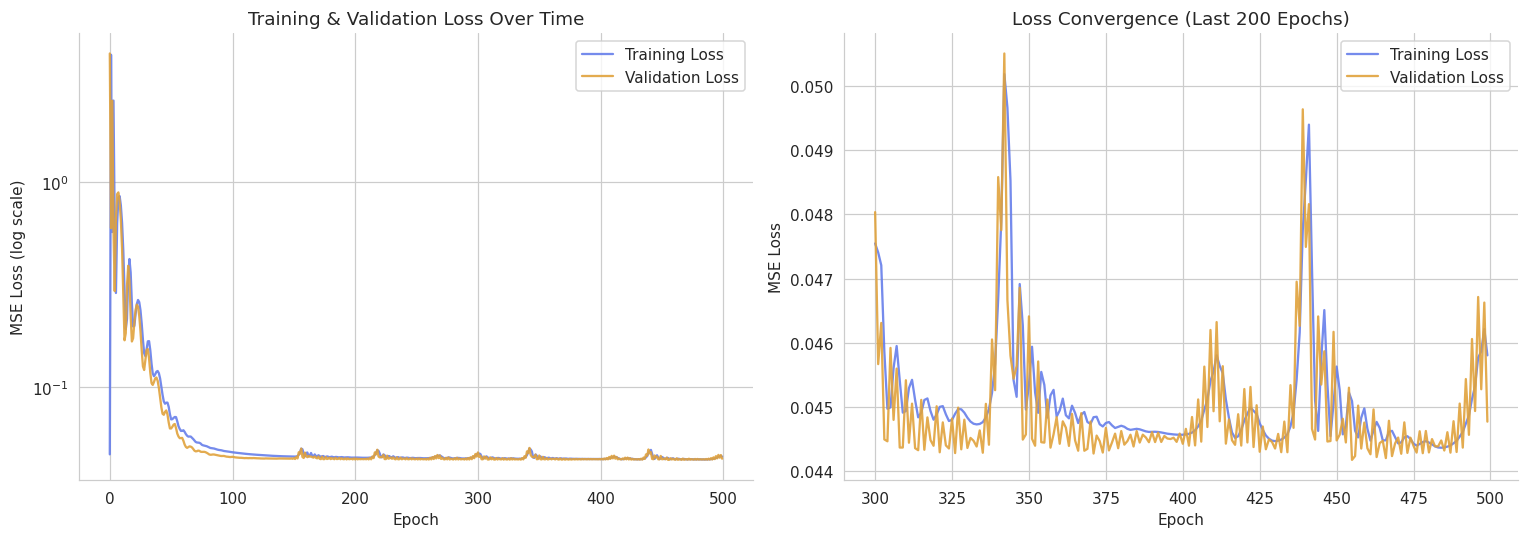

Final Training Loss:   0.0458
Final Validation Loss: 0.0448


In [27]:
# How the training and validation loss changed over time
plot_training_history(train_losses, val_losses)

### 📖 Reading the curves

The left panel is on a **log scale**, so a straight downward line means the loss is falling by a
constant *factor* — most of the learning happens in the first few hundred epochs, and the rest
is refinement. The right panel zooms into the final stretch, where the two curves flatten and
sit close together.

**Close together is the point.** A validation curve that tracks the training curve means the
model is learning the market, not the archive. A large and growing gap between them would be
the picture of a model memorising the ~8,000 properties in the training split — and one that would embarrass you
on the first listing it had never seen.

---

# 📏 5. Model Evaluation

Now the honest test: how well does the model price properties **it has never seen**? We use the
test set, held back from both training and validation, and we report the errors in **dollars**,
because that is the unit your head of sales thinks in.

Four metrics, each answering a different question:

**MAE — Mean Absolute Error.** The average miss, in dollars.

$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n} \lvert \hat{y}_i - y_i \rvert$$

where $n$ is the number of test properties, $y_i$ the price property $i$ actually sold for, and
$\hat{y}_i$ the price the model predicted. *"On a typical property, how far off are we?"*

**RMSE — Root Mean Squared Error.** Same idea, but errors are squared before averaging, so a few
large misses dominate.

$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (\hat{y}_i - y_i)^2}$$

*"How badly do we get it wrong when we get it wrong?"* An RMSE much larger than the MAE is the
signature of a model that is usually fine but occasionally catastrophic — which for a valuation
desk is far more dangerous than being mildly wrong everywhere.

**MAPE — Mean Absolute Percentage Error.** The average miss as a percentage of the true price.

$$\text{MAPE} = \frac{100}{n}\sum_{i=1}^{n} \left\lvert \frac{\hat{y}_i - y_i}{y_i} \right\rvert$$

*"How far off are we, relative to what the property is worth?"* This is the one that travels: a
$40,000 error is a rounding difference on a mansion and a disaster on a studio flat.

**$R^2$ — Coefficient of Determination.** The proportion of variance in the data explained by the model.

$$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$

where $\bar{y}$ is the average sale price across all test properties. This is a commonly reported metric for regression analysis which asks:

*"How much better is our model than just guessing the average every single time?"* An $R^2$ of $1.0$ means flawless predictions, while an $R^2$ of $0$ means you might as well ditch the model and quote the market average for everything. In simple terms, it measures how well a regression model fits the actual observed data. The goal of regression is to drive this up as close to 1 as possible. It is also the squared correlation between the predictions and the actual values.

The helper also breaks each metric down **by price quartile** — and that breakdown, not the
headline number, is what answers your original question.

In [28]:
# Predict on the test set and convert the predictions back into dollars
test_predictions = get_predictions(model, test_features_t, price_scaler)

In [29]:
# MAE, RMSE and MAPE — overall, and split by price range
print_performance_metrics(test_prices_original, test_predictions, show_r2=True)

           OVERALL TEST SET PERFORMANCE

   MAE  (Mean Absolute Error):      $16,530.20
   RMSE (Root Mean Squared Error):  $20,344.51
   MAPE (Mean Absolute % Error):    7.23%
   R²   (Coefficient of Determination): 0.9532


           PERFORMANCE BY QUARTILE

  Range 1: $59,859 → $197,815
     MAE:  $16,188.05   RMSE: $20,002.63   MAPE: 11.63%

  Range 2: $197,815 → $261,133
     MAE:  $16,399.77   RMSE: $20,546.88   MAPE: 7.20%

  Range 3: $261,133 → $326,426
     MAE:  $16,635.67   RMSE: $20,094.01   MAPE: 5.72%

  Range 4: $326,426 → $611,248
     MAE:  $16,879.99   RMSE: $20,723.74   MAPE: 4.37%


### 📖 Reading the result — and the decision it supports

Three things to take from this printout, in order of business importance:

1. **The headline MAPE is your automation budget.** An estate agent will happily accept a price
   estimate that is a few percent off — that is inside the normal haggling range on any sale. If
   the MAPE is in the low single digits, the model is competitive with a quick human appraisal.
2. **RMSE versus MAE tells you about the tail.** RMSE is always the larger of the two; the
   question is *how much* larger. A big gap means a minority of properties are being priced
   badly, and those are the ones that produce an angry vendor and a lost mandate.
3. **The quartile breakdown is the actual recommendation.** Look at which price range has the
   worst MAPE — typically the cheapest and the most expensive, where the archive holds fewest
   comparable sales. That is the split you take to your head of sales:

> *"Automate the middle of the market, where the model is within a few percent and we have
> thousands of comparable sales. Keep the appraiser on the top and bottom quartiles, where the
> data is thin and the errors are largest."*

That sentence is the deliverable. The network was just how you earned the right to say it.

---

# 📈 6. Prediction Visualisations

Numbers summarise; pictures show you *where* the model fails. Three charts:

1. **Predicted vs actual** — every test property as a dot. A perfect model puts them all on the
   diagonal; the shape of the spread around it tells you where confidence breaks down.
2. **Error distribution** — a narrow bell centred on zero is what you want. Centred anywhere
   else means the model is systematically over- or under-pricing.
3. **20 sample properties** — actual and predicted side by side, the closest thing to what an
   agent would actually see on screen.

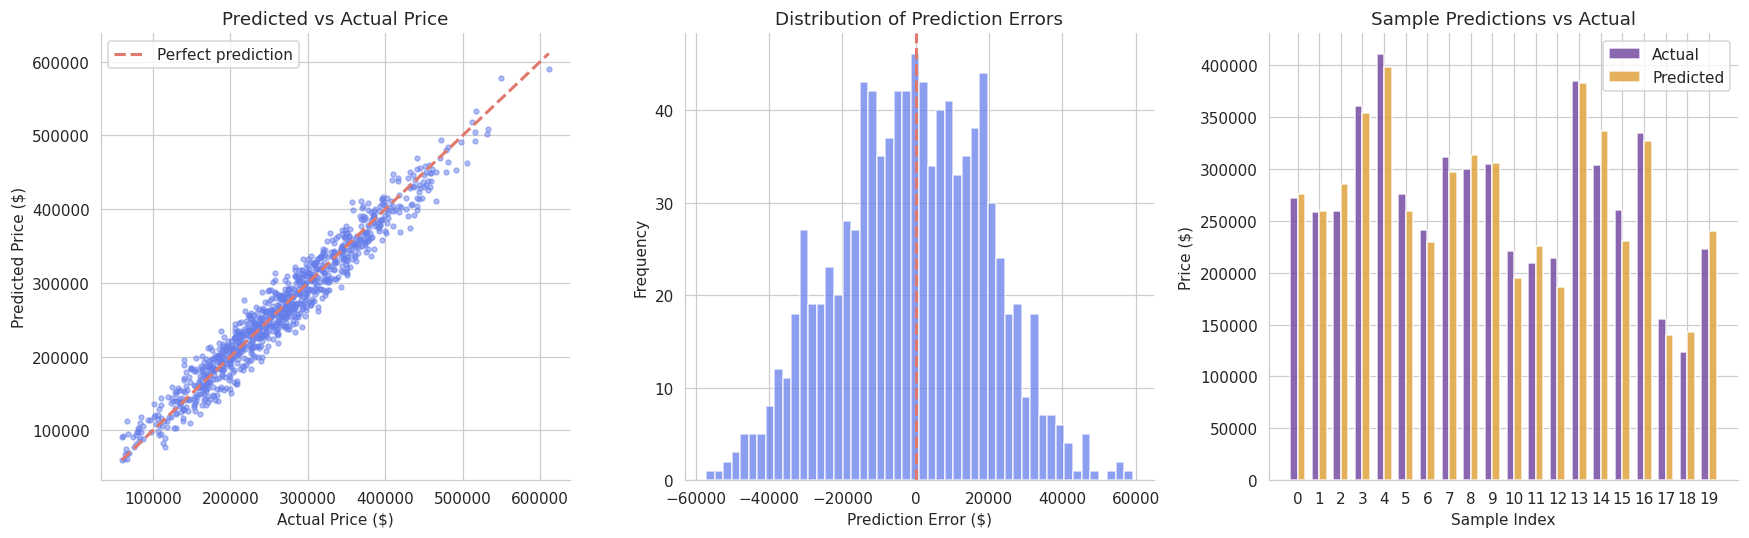

In [30]:
# Three charts comparing predictions against the real sold prices
plot_predictions(test_prices_original, test_predictions)

### 📖 Reading the charts

- **The dots hug the diagonal in the middle and fan out at the edges.** That is the quartile
  breakdown again, in visual form: the model is most reliable where your archive is densest.
- **A bell centred on zero means no systematic bias** — the model is not quietly over-pricing
  every listing. If the bell were shifted right, every property would go to market too dear, and
  you would find out through listings that sit unsold.
- **The sample bar chart is your credibility test.** These twenty pairs are what you show the
  sales meeting. If most bars nearly match and the few that miss are visibly the extreme
  properties, the story you tell in Part 5 holds up in front of an audience.

---

## 🎯 Summary

You built a complete neural network pipeline, end to end:

1. **Looked at the data first.** Size dominates, but no single feature explains a price — which
   is what justified a model over a spreadsheet formula in the first place.
2. **Split three ways and scaled on the training set only.** The test set stayed untouched until
   the end, which is the only reason the final number means anything.
3. **Built a 4-layer network** (4 → 128 → 128 → 64 → 1) with ReLU activations — 25,473
   parameters learning from roughly 8,000 training properties.
4. **Trained with early stopping.** With 25,473 parameters and ~8,000 rows, knowing when
   to stop mattered more than any other choice in the notebook.
5. **Reported errors in dollars, not in loss units.** MAE, RMSE and MAPE each answer a different
   question, and the gap between MAE and RMSE is where the expensive mistakes hide.
6. **Turned the numbers into a recommendation:** automate the middle of the market, keep the
   appraisers on the segments where the data is thin. A model that knows *where* it is unreliable
   is worth more to the business than a model with a slightly better average.

### What's next

The model works, but nothing about it has been tuned. In the **next notebook** we keep this
exact problem and improve the result with a handful of standard techniques — mini-batch
training, a log-transformed target, and a few architectural additions — and measure what each
one actually buys you.